![FaMAF-UNC](https://drive.google.com/uc?export=download&id=1k4tzcXOoq6TrkDEW_Ox8o4Y4pAHzKHb7
)
> Docentes: **Damián Fernández** y **Leandro Milne**
>> Teórico del 28-04-2021


# Funciones de varias variables

## Funciones diferenciables

### Ecuaciones en Derivadas Parciales

Ahora que conocemos cómo definir las derivadas parciales de todo orden de una función podremos dar ejemplos de ecuaciones diferenciales. En muchas aplicaciones no se conoce la función que modela matemáticamente el problema, pero sí se conocen propiedades de tal función, como velocidad, aceleración, curvatura, etc. que pueden describirse a través de las derivadas parciales de esta función desconocida. Por lo tanto, el problema matemático consiste en hallar la función tal que sus derivadas parciales cumplen con las propiedades requeridas.





#### Ejemplo

Considere que nuestra función desconocida $u$ es aquella que describe el perfil de una ola que se mueve hacia la derecha con velocidad $c$ m/s tomando en cuenta una sola variable espacial. O sea $u:\mathbb{R}^2 \to \mathbb{R}$ tal que $u(x,t)$ es la altura de la ola en la posición $x$ en el tiempo $t$.

In [ ]:
#@title Ola con velocidad constante { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from matplotlib import rc
rc('animation', html='jshtml')

def fun_g(x, der=False):
  # h(x) = exp(-(x-1)**2/4)
  tmp = x - 1
  f = np.exp(-tmp**2/4)
  if der:
    df = -tmp/2*f
    return f, df
  else:
    return f

tini = 0; tfin = 2.1; nt = 10
xini = -2; xfin = 7; nx = 100
vt = np.linspace(tini,tfin,nt)
vx = np.linspace(xini,xfin,nx)
c = 1.5
u = np.zeros(nx)


fig, ax = plt.subplots()
#fig.suptitle("ola con velocidad constante")
plt.close()


def animacion(j):
  ax.clear()
  t=vt[j]
  for i in range(nx):
    x=vx[i]
    u[i] = fun_g(x - c*t)
  ax.plot(vx, u, color=[j/nt,0,1-j/nt])
  ax.axis('off')
  plot = ax.axis('equal');
  return plot

#plt.savefig('ejm_transporte.pdf')

anim = animation.FuncAnimation(fig, animacion, frames=range(nt), repeat = False)

anim


Si fijamos una altura $h = u(\bar{x},\bar{t})$ sabemos que luego de $t$ segundos el perfil avanza $ct$ metros, o sea $h=u(\bar{x}+ct,\bar{t}+t)$. Aplicando regla de la cadena y evaluando en $t=0$, obtenemos que
$$
 0 = \frac{d h}{dt} = c \frac{\partial u}{\partial x}(\bar{x}+ct,\bar{t}+t)\Big|_{t=0} + \frac{\partial u}{\partial t}(\bar{x}+ct,\bar{t}+t)\Big|_{t=0}
    = c \frac{\partial u}{\partial x}(\bar{x},\bar{t}) + \frac{\partial u}{\partial t}(\bar{x},\bar{t}).
$$
Como $(\bar{x},\bar{t})$ fue arbitrario, obtenemos que la función $u$ debe satisfacer la ecuación en derivadas parciales
$$
     \frac{\partial u}{\partial t}(x,t) + c \frac{\partial u}{\partial x}(x,t) = 0,
$$
para todo $(x,t)$.

De la deducción, se desprende que si se conoce el perfil en algún instante de tiempo, conoceremos el perfil en todo tiempo. En este caso, si conocemos un perfil de ola $g$ tal que $u(x,0)=g(x)$ entonces se puede ver que $u(x,t)=g(x-ct)$ es la solución de la ecuación diferencial.

---

Si en el ejemplo anterior se consideran $n$ variables espaciales, con una deducción similar obtendremos la ecuación de transporte
$$
     0 = \frac{\partial u}{\partial t}(x,t) + c_1 \frac{\partial u}{\partial x_1}(x,t)
        + \ldots + c_n \frac{\partial u}{\partial x_n}(x,t)
        = \frac{\partial u}{\partial t}(x,t) + \langle c , \nabla u (x,t) \rangle,
$$
para todo $(x,t)\in\mathbb{R}^n \times \mathbb{R}$.


Veamos un ejemplo como el anterior pero donde la velocidad no es constante.

#### Ejemplo

Considere que nuestra función desconocida $u$ es aquella que describe la altura de una ola que se acerca a la costa. Debido a la fricción con el fondo, la parte baja de la ola se desplaza a menor velocidad que la parte alta.

In [ ]:
#@title Ola llegando a la costa { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from matplotlib import rc
rc('animation', html='jshtml')

#0=u - g( x-t u ).
def auxfun(u, der=False):
  z = x - t*u
  if der:
    g, dg = fun_g(z, True)
    f = u - g
    df = 1+t*dg
    return f, df
  else:
    g = fun_g(z)
    f = u - g
    return f

def rNewton(f, x0, ftol=1e-10, xtol=1e-10, Niter=100, historico=False, imprimir=True):
  '''Ejecuta el método de Newton para hallar una raíz de f, donde
    f: función a valores reales que retorne la derivada
        fun,Dfun=f(x,True)
    x0: punto inicial
    ftol: tolerancia de error en f
    xtol: tolerancia de error en x
    Niter: máximo de iteraciones permitidas
    historico: True o False para retornar todas las iteraciones
    imprimir: True o False para imprimir mensaje
  El método para si |f(x_k)|<ftol y |x_k-x_{k-1}|<xtol, o k=Niter'''
  x = x0
  if historico:
    xhist = [x]
  else:
    xhist = x
  paradaX = True
  for k in range(Niter):
    fx, Dfx = f(x, True)
    paradaF = (abs(fx)<ftol)
    if paradaF and paradaX:
      if imprimir:
        print("La raíz es x=",x)
      return xhist
    paradaDF = (abs(fx)+abs(Dfx)>abs(fx))
    if not paradaDF:
      if imprimir:
        print("La derivada de la función es ",Dfx)
      return xhist
    d = -fx/Dfx
    paradaX = (abs(d)<xtol)
    x = x + d
    if historico:
      xhist.append(x)
    else:
      xhist = x

  if imprimir:
    print("Máximo de iteraciones alcanzado")
  return xhist


def fun_ola(x, t):
  return rNewton(auxfun, 1, imprimir=False)

u = np.zeros(nx)
fig, ax = plt.subplots()
plt.close()

def animacion(j):
  global x, t
  ax.clear()
  t=vt[j]
  for i in range(nx):
    x=vx[i]
    u[i] = fun_ola(x, t)
  ax.plot(vx, u, color=[j/nt,0,1-j/nt])
  ax.axis('off')
  plot = ax.axis('equal');
  return plot

#plt.savefig('ejm_ola.pdf')

anim = animation.FuncAnimation(fig, animacion, frames=range(nt), repeat = False)

anim



En este caso, la velocidad de desplazamiento es proporcional a la altura. Supongamos que la constante de proporcionalidad es uno, o sea, la velocidad en la posición $x$ en el tiempo $t$ es igual a $u(x,t)$. Suponga ahora que para una altura fija $h$ defino $\gamma$ tal que para cada tiempo $t$ obtengo $h = u(\gamma(t),t)$. En este caso, si $x=\gamma(t)$, entonces $\gamma'(t)$ es la velocidad de desplazamiento espacial en el punto $(x, t)$, o sea $\gamma'(t) = u(x,t)$. Usando regla de la cadena obtenemos que
$$
 0 = \frac{d h}{dt} (t) = \frac{\partial u}{\partial x} (x,t) u(x,t) + \frac{\partial u}{\partial t} (x,t).
$$
Por lo tanto, $u$ es la función que resuelve la ecuación diferencial
$$
\frac{\partial u}{\partial t}(x,t) + u(x,t) \frac{\partial u}{\partial x}(x,t) =0,
$$
para todo $(x,t)$. Similar al caso anterior, si para algún tiempo, digamos $t=0$, la ola tiene un perfil dado por la función $g$, o sea $u(x,0)=g(x)$, se puede verificar que la función $u:\mathbb{R}^2 \to \mathbb{R}$ es aquella definida implícitamente por
$$
0=u(x,t) - g\bigl(x-t\,u(x,t)\bigr),
$$
y que la misma puede definirse en cierta región espacio-temporal, debido a que cuando la ola crea una pared vertical se tiene que $u$ no es una función.

---

Veamos un ejemplo con derivadas de segundo orden.

#### Ejemplo

Considere que se desea conocer la función que determina la temperatura de una barra de hierro (i.e., espacio unidimensional) sometida a una fuente de calor. Sea $u(x,t)$ es la temperatura de la barra y $f(x,t)$ la fuente de calor, en la posición $x$ en el tiempo $t$. Como el calor se desplaza de los lugares de mayor concentración a los de menor concentración, se origina un flujo $F(x,t) = -\kappa \frac{\partial u}{\partial x}(x,t)$ ya que menos la derivada apunta a los lugares de menor concentración y $\kappa$ es la constante de difusión del medio.


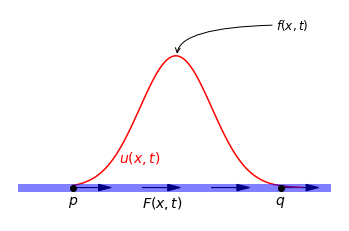

In [ ]:
#@title Calor en una barra { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

for i in range(nx):
  u[i] = 10*fun_g(vx[i]-c*vt[3])

plt.plot(vx, u, color='r')
plt.plot([-4, 8], [0,0], color='b', linewidth=8, alpha=0.5)
for i in range(0,nx,30):
  plt.arrow(vx[i], 0, 1, 0, head_width=0.5, head_length=0.5, color='k')
plt.plot([vx[0], vx[90]], [0,0], 'ko')
plt.text(vx[0], -0.5, '$p$', fontsize=14, verticalalignment='top', horizontalalignment='center')
plt.text(vx[90], -0.5, '$q$', fontsize=14, verticalalignment='top', horizontalalignment='center')
plt.text(vx[30], -0.5, '$F(x,t)$', fontsize=14, verticalalignment='top', horizontalalignment='left')
plt.text(vx[20], u[20], '$u(x,t)$', fontsize=14, verticalalignment='top', horizontalalignment='left', color='r')
plt.annotate('$f(x,t)$', fontsize=12,xy=(vx[45], u[45]), xytext=(6,12),arrowprops=dict(arrowstyle="->",connectionstyle="angle3,angleA=0,angleB=-90"))
plt.plot([-2, 6], [13,-2], 'wo')
plt.axis('off');
#plt.savefig('ejm_calor.pdf')




Si consideramos dos puntos arbitarios de la barra, $p$ y $q$, tendremos que en el sector de la barra entre $p$ y $q$ la variación de la concentración de calor debe ser igual al flujo entrante menos el flujo saliente más el calor aportado por la fuente. O sea
\begin{align*}
    \frac{\partial}{\partial t} \int_p^q u(x,t) dx
    &= F(p,t) - F(q,t) + \int_p^q f(x,t) dx \\
    &= \int_p^q \left( -\frac{\partial F}{\partial x}(x,t) + f(x,t) \right) dx,
\end{align*}
o sea,
$$
  \int_p^q \left( \frac{\partial u}{\partial t}(x,t)
  - \kappa \frac{\partial^2 u}{\partial x^2}(x,t)
  - f(x,t) \right) dx = 0.
$$
Como esto vale para $p$ y $q$ arbitrarios, obtenemos que el integrano debe ser cero siempre. De esta manera obtenemos que $u$ debe ser solución de la ecuación en derivadas parciales
$$
 \frac{\partial u}{\partial t}(x,t) - \kappa \frac{\partial^2 u}{\partial x^2}(x,t) = f(x,t),
$$
para todo $(x,t)$.

---

Si consideramos $n$ variables espaciales en el ejemplo anterior, con una deducción similar obtendremos la ecuación del calor
$$
 \frac{\partial u}{\partial t}(x,t)
 - \kappa \Delta u(x,t) = f(x,t),
$$
para todo $(x,t)\in \mathbb{R}^n \times \mathbb{R}$, donde
$$
    \Delta u (x,t) = \frac{\partial^2 u}{\partial x_1^2}(x,t) + \ldots + \frac{\partial^2 u}{\partial x_n^2}(x,t),
$$
se conoce como el Laplaciano de $u$.


# Curvas y superficies

Con la teoría desarrollada hasta el momento, podremos dar una interpretación gráfica de varios conceptos y analizar su importancia y propiedades a través de figuras.


## Curvas

Una curva es efectivamente el diseño que uno suele realizar de una recta, una parábola o un círculo en el plano. También lo es un resorte o una figura de alambre en el espacio. Veamos cómo formalizar esa noción.

>**Definición**
>
> Una **trayectoria** en $\mathbb{R}^n$ es una función $\gamma:[a,b] \to \mathbb{R}^n$. Los puntos $\gamma(a)$ y $\gamma(b)$ se llaman **extremos** de la trayectoria. La imagen de $\gamma$ se llama **curva** de $\gamma$.

Por lo tanto, una curva es el conjunto definido paramétricamente por una trayectoria. Además, se dice que una trayectoria es continua, diferenciable, dos veces diferenciable, etc., si la función $\gamma$ tiene tal propiedad.


Por ejemplo, el segmento en $\mathbb{R}^n$ que une $x$ e $y$ es la curva definida por la trayectoria $\gamma:[0,1] \to \mathbb{R}^n$ tal que $\gamma(t) = x + t (y-x)$.

La trayectoria $\sigma:[0, 2\pi] \to \mathbb{R}^3$ tal que $\sigma(t) = \bigl(\cos(t), 0, \operatorname{sen}(t) \bigr)$ tiene como curva una circunferencia en $\mathbb{R}^3$. Si consideramos $p:[-1,1] \to \mathbb{R}$ tal que $p(t) = 2\pi(1-t^2)$, entonces la trayectoria $\sigma \circ p$ es una trayectoria cuya curva coincide con la de $\sigma$.


In [ ]:
#@title Dos trayectorias, una curva { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.animation as animation

from matplotlib import rc
rc('animation', html='jshtml')

fig = plt.figure(figsize=plt.figaspect(0.5))
ax1 = fig.add_subplot(1,2,1,projection='3d')
ax2 = fig.add_subplot(1,2,2,projection='3d')
plt.close()

th = np.linspace(0,2*np.pi,200)
t = np.linspace(-1,1,200)
tt = 2*np.pi*(1-t**2)
circulo = np.array([np.cos(th), np.zeros(200), np.sin(th)])
circulot = np.array([np.cos(tt), np.zeros(200), np.sin(tt)])

def animacion(i):
  ax1.clear()
  ax2.clear()

  ax1.plot3D([0,0],[-1.2,1.2], [0,0], color=(0.5,0.5,0.5))
  ax1.plot3D([-1.2,1.2], [0,0], [0,0], color=(0.5,0.5,0.5))
  ax1.plot3D([0,0], [0,0], [-1.2,1.2], color=(0.5,0.5,0.5))
  ax1.plot3D(circulo[0], circulo[1], circulo[2], color='b')
  ax1.plot3D([circulo[0,i]], [circulo[1,i]], [circulo[2,i]], 'ro')
  ax1.set_title(r'$\sigma$')

  ax2.plot3D([0,0],[-1.2,1.2], [0,0], color=(0.5,0.5,0.5))
  ax2.plot3D([-1.2,1.2], [0,0], [0,0], color=(0.5,0.5,0.5))
  ax2.plot3D([0,0], [0,0], [-1.2,1.2], color=(0.5,0.5,0.5))
  ax2.plot3D(circulot[0], circulot[1], circulot[2], color='b')
  ax2.plot3D([circulot[0,i]], [circulot[1,i]], [circulot[2,i]], 'ro')
  plot = ax2.set_title(r'$\sigma \circ p$')
  return plot

anim = animation.FuncAnimation(fig, animacion, frames=range(0,200,3), repeat = False)

anim
#plt.savefig('ejm_cicloide.pdf')

Claramente, si una trayectoria $\gamma$ en $\mathbb{R}^n$ tiene derivada en $\bar{t}$ tendremos que
$$
    \gamma'(\bar{t}) = \lim_{h \to \bar{t}} \frac{\gamma(\bar{t} + h) - \gamma(\bar{t})}{h}
    = \left[\begin{array}{c} \gamma_1'(\bar{t}) \\ \vdots \\ \gamma_n'(\bar{t}) \end{array} \right].
$$

Si pensamos a $\gamma$ como la función que a cada instante de tiempo nos retorna la posición de una partícula, entonces $(\gamma(\bar{t} + h) - \gamma(\bar{t}))/h$ es la velocidad promedio de la partícula en el intervalo de tiempo de $\bar{t}$ a  $\bar{t}+h$. De esta manera, claramente $\gamma'(\bar{t})$ es el vector **velocidad** en $\bar{t}$ y su magnitud $\|\gamma'(\bar{t})\|$ es la **rapidez** de la partícula. Naturalmente, la **aceleración** de la partícula en el instante $\bar{t}$ vendrá dada por $\gamma''(\bar{t})$.



Por otro lado, la noción de derivada suele asociarse a la idea de una curva tangente. Esto no siempre es cierto. Note que por un lado, que la derivada es un concepto analítico que depende de la definición de una función. Por otro lado, un vector tangente a un conjunto es un concepto geométrico que depende únicamente de la forma del conjunto. Formalicemos este último concepto.

>**Definición**
>
> La distancia de un punto $x$ a un conjunto $S$ en $\mathbb{R}^n$ se define como
$$
\operatorname{d}(x,S) = \inf_{y \in S}  \operatorname{d}(x,y) = \inf_{y\in S} \|y - x\|.
$$
Se dice que un vector $v$ es tangente a $S$ en $x$ si
$$
    \lim_{t\to 0^+} \frac{\operatorname{d}(x + t v ,S)}{t} = 0,
$$
o sea, $\operatorname{d}(x + t v ,S) = o(t)$.



De la definición se puede ver que si $v$ es tangente entonces $\alpha v$ es tangente para todo $\alpha >0$.

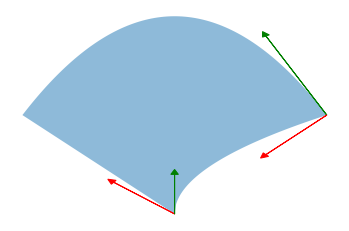

In [ ]:
#@title Tangentes { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(0,1,100)
y1 = np.sqrt(x1)
x2 = np.flip(np.linspace(-1,1,100))
y2 = 2-x2**2
x3 = np.linspace(-1,0,100)
y3 = np.abs(x3)
plt.fill(np.concatenate((x1,x2,x3)), np.concatenate((y1,y2,y3)), alpha=0.5)
l = 0.4
plt.arrow(0,0,-l,0.8*l,head_width=0.05, head_length=0.05,color='r')
plt.arrow(0,0,0,l,head_width=0.05, head_length=0.05,color='g')
plt.arrow(1,1,-l,2*l,head_width=0.05, head_length=0.05,color='g')
plt.arrow(1,1,-l,-l,head_width=0.05, head_length=0.05,color='r')
plt.axis('off');
#plt.savefig("tangentes.pdf")

Note que por más que nuestro conjunto sea una curva, el conjunto de vectores tangentes puede no ser una recta. Por ejemplo, la curva lemniscata se cruza en el origen y los vectores tangentes en ese punto es la unión de dos rectas.

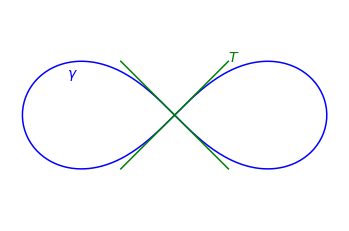

In [ ]:
#@title Lemniscata { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

th = np.linspace(-np.pi,np.pi,200)
r = np.sqrt(2)/(1+np.cos(th)**2)
plt.plot(r*np.sin(th), r*np.sin(th)*np.cos(th), color='b')
plt.text(-1, 0.35, r'$\gamma$', color='b', fontsize=14)
plt.plot([-0.5,0.5], [-0.5,0.5], color='g')
plt.plot([-0.5,0.5], [0.5,-0.5], color='g')
plt.text(0.5,0.5,'$T$', color='g', fontsize=14)
#plt.title('Lemniscata')
plt.axis('off')
plt.axis('equal');
plt.savefig("lemniscata.pdf")

Veamos estas nociones en el siguiente ejemplo.

#### Ejemplo

Sea $S = \{ x \in \mathbb{R}^2 \mid \|x\|=1\}$ la circunferencia unitaria y considere dos trayectorias que describen esta curva: $\gamma:[-1, 1] \to \mathbb{R}^2$ tal que $\gamma(t) = \bigl( \cos(\pi t), \operatorname{sen}(\pi t) \bigr)$ y $\sigma:[-1, 1] \to \mathbb{R}^2$ tal que $\sigma(t) = \bigl( \cos(2\pi(1-t^2)), \operatorname{sen}(2\pi(1-t^2)) \bigr)$.


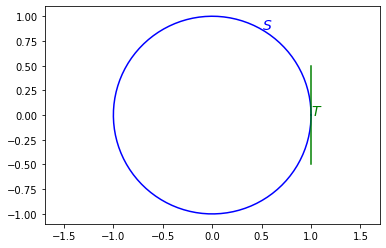

In [ ]:
#@title Circunferencia unitaria { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

th = np.linspace(0,2*np.pi,200)
plt.plot(np.cos(th), np.sin(th), color='b')
plt.text(0.5, 0.5*3**0.5, '$S$', color='b', fontsize=14)
plt.plot([1,1], [-0.5,0.5], color='g')
plt.text(1,0,'$T$', color='g', fontsize=14)
plt.axis('equal');
#plt.axis('off')
#plt.savefig("ejm_circunittangent.pdf")




Veamos primero que $\operatorname{d}(x,S) = | \|x\| - 1 |$. Como $|\|x\| - \|y\| | \leq \|x - y\|$, para cualquier $y \in S$ tenemos
$$
    \left\|x - \frac{x}{\|x\|}\right\| = \frac{1}{\|x\|} \| (\|x\| - 1) x \|
    = | \|x\| - 1 | = |\|x\| - \|y\| | \leq \|x - y\|,
$$
obteniendo que el ínfimo se alcanza en $x/\|x\| \in S$ y $\operatorname{d}(x,S) = | \|x\| - 1 |$.


Ahora podemos ver que $T=\{v\in\mathbb{R}^2 \mid v_1=0\}$ es el conjunto de vectores tangentes a $S$ en $\bar{x} = (1,0)$. Por lo anterior, para cualquier $v\in\mathbb{R}^2$ se tiene
$$
\operatorname{d}(\bar{x}+ tv,S) = | \|\bar{x}+ tv\| - 1 |
    = |\sqrt{(1+tv_1)^2 + (tv_2)^2} - 1|
    = \frac{|2tv_1 + t^2 v_1^2  + t^2 v_2^2|}{\sqrt{(1+tv_1)^2 + (tv_2)^2} + 1}.
$$
Por lo tanto si $v$ es tangente tendremos $0 = \lim_{t \to 0^+} \frac{1}{t}\operatorname{d}(\bar{x}+ tv,S) = |v_1|$. Concluyendo que $v\in T$. Por otro lado, si $v\in T$ entonces
$$
\operatorname{d}(\bar{x}+ tv,S)   
    = \frac{t^2 v_2^2 }{\sqrt{1 + (tv_2)^2} + 1} = o(t).
$$

Para $\bar{t}=0$ tenemos que $\gamma(\bar{t}) = \bar{x}$ y $\sigma(\bar{t}) = \bar{x}$. Como
$$
    \gamma'(t)= \bigl( -\pi \operatorname{sen}(\pi t), \pi \cos(\pi t)\bigr),
$$
tenemos que $\gamma'(\bar{t}) = (0,\pi)$ y la recta $\{ \alpha \gamma'(\bar{t}) \mid \alpha \in \mathbb{R} \}$ coincide con $T$. Por otro lado
$$
    \sigma'(t)= \bigl( 4\pi t \operatorname{sen}(2\pi(1-t^2)), -4\pi t \cos(2\pi(1-t^2))\bigr),
$$
y $\sigma'(\bar{t})=(0,0)$, no pudiendo generar $T$.

---



>**Teorema**
>
> Si $\gamma$ es una trayectoria diferenciable y $\gamma'(\bar{t}) \neq 0$, entonces la recta dada en forma paramétrica por $t \mapsto \gamma(\bar{t}) + (t-\bar{t}) \gamma'(\bar{t})$ es tangente a la curva de $\gamma$ en $\gamma(\bar{t})$.


Supongamos ahora que tenemos una trayectoria $\gamma$ en $\mathbb{R}^3$ tal que para todo tiempo su rapidez $v(t) = \| \gamma'(t) \| \neq 0$. Entonces $T(t) = \gamma'(t) / v(t)$ es un **vector tangente unitario**, pues $\|T(t)\| =1$. Como $\gamma'(t) = v(t) T(t)$, el vector aceleración es $\gamma''(t) = v'(t) T(t) + v(t) T'(t)$. Si $T'(t)=0$ entonces la aceleración tiene la misma dirección o la opuesta a la dirección del movimiento. Si $T'(t) \neq 0$, usando que $\|T(t)\|^2 =1$ se obtiene
$$
    0 = \frac{d}{dt} (T_1^2 + T_2^2 + T_3^2)(t) = 2 T_1'(t) T_1(t) + 2 T_2'(t) T_2(t) + 2 T_3'(t) T_3(t)
        = 2 \langle T'(t), T(t) \rangle.
$$
De esta manera, podemos definir el **vector normal unitario** $N(t) = T'(t)/\|T'(t)\|$. Con esto
$$
    \gamma''(t) = v'(t) T(t) + v(t) \|T'(t)\| N(t),
$$
descomponiendo la aceleración en sus componentes tangenciales y normales. Como estamos en $\mathbb{R}^3$ podemos completar la base con un tercer vector $B(t)$, llamado **vector binormal**, definido como $B(t) = T(t) \times N(t)$. Juntos, $T$, $N$ y $B$ forman un sistema ortogonal móvil a lo largo de la curva, conocido como **marco de Frenet-Serret**.
